## 1 Importation des données et des librairies

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

dataset_path = kagglehub.dataset_download("bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset")
print(f"Data cached at: {dataset_path}")

df = pd.read_csv(f"{dataset_path}/healthcare_synthetic_data.csv")

/Users/felixdecker/miniconda3/envs/ML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data cached at: /Users/felixdecker/.cache/kagglehub/datasets/bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset/versions/1


In [4]:
# =============================================================================
# FONCTIONS POUR L'OPTIMISATION DU SEUIL 
# =============================================================================

from sklearn.metrics import fbeta_score, recall_score, precision_score, f1_score, precision_recall_curve, average_precision_score

def find_optimal_threshold_f1(y_true, y_proba, n_thresholds=100):
    """Trouve le seuil optimal qui maximise le F1-score (comme en R)"""
    thresholds = np.linspace(0, 1, n_thresholds)
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            
    return best_threshold, best_f1

def evaluate_with_threshold(y_true, y_proba, threshold):
    """Évalue un modèle avec un seuil donné"""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'f2': fbeta_score(y_true, y_pred, beta=2)
    }

In [5]:
df["Gender"] = pd.Categorical(df["Gender"], ordered=False)
df["Smoking_Status"] = pd.Categorical(df["Smoking_Status"], ordered=False)
df["Physical_Activity_Level"] = pd.Categorical(df["Physical_Activity_Level"], ordered=True)
df["Alcohol_Consumption"] = pd.Categorical(df["Alcohol_Consumption"], ordered=True)
df["Family_History"] = pd.Categorical(df["Family_History"], ordered=False)
df["Heart_Disease_Risk"] = pd.Categorical(df["Heart_Disease_Risk"], ordered=False)

# Modélisation

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [7]:
df_model = df.drop(columns=["Patient_ID"])

df_encoded = pd.get_dummies(df_model, columns=["Gender", "Smoking_Status",
                                                "Physical_Activity_Level",
                                                "Alcohol_Consumption",
                                                "Family_History"],
                             drop_first=True)

labels_risk = ["Faible risque", "Risque élevé"]

print("Dimension des données encodées :", df_encoded.shape)

Dimension des données encodées : (15000, 21)


In [8]:
df_model["Stress_Level"] = pd.Categorical(df_model["Stress_Level"])
df_model["Sleep_Hours"] = pd.Categorical(df_model["Sleep_Hours"])

print("Stress_Level et Sleep_Hours transformées en variables catégorielles")

print(f"Modalités Sleep_Hours : {df_model['Sleep_Hours'].cat.categories.tolist()}")
print(f"Modalités Stress_Level : {df_model['Stress_Level'].cat.categories.tolist()}")

# Ré-encoder avec ces nouvelles catégories
df_encoded = pd.get_dummies(df_model, 
                             columns=["Gender", "Smoking_Status", "Physical_Activity_Level",
                                      "Alcohol_Consumption", "Family_History", 
                                      "Stress_Level", "Sleep_Hours"],
                             drop_first=True)

print(f"Dimension des données encodées : {df_encoded.shape}")

Stress_Level et Sleep_Hours transformées en variables catégorielles
Modalités Sleep_Hours : [4, 5, 6, 7, 8, 9, 10]
Modalités Stress_Level : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Dimension des données encodées : (15000, 34)


In [9]:
y_classif = df_encoded["Heart_Disease_Risk"].cat.codes.values
X_classif = df_encoded.drop(columns=["Heart_Disease_Risk"]).values
feature_names_classif = df_encoded.drop(columns=["Heart_Disease_Risk"]).columns

Xtrain_c, Xtest_c, ytrain_c, ytest_c = train_test_split(
    X_classif, y_classif, test_size=0.2, random_state=42, stratify=y_classif)

scaler_c = StandardScaler()
Xtrain_c_sc = scaler_c.fit_transform(Xtrain_c)
Xtest_c_sc  = scaler_c.transform(Xtest_c)

print("Echantillon d'apprentissage :", Xtrain_c.shape[0], "observations")
print("Echantillon test            :", Xtest_c.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


# 1 Prédiction du risque d'accident cardiaque — `Heart_Disease_Risk`

## 1.1 Modèles linéaires

### 1.1.1 Régression logistique

#### Estimation sans régularisation

In [10]:
from sklearn.linear_model import LogisticRegression

ts = time.time()
logit = LogisticRegression(solver='liblinear', max_iter=1000)
logit.fit(Xtrain_c, ytrain_c)
te = time.time()

# Probabilités
y_proba_logit = logit.predict_proba(Xtest_c)[:, 1]

# Optimisation du seuil
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_logit)
metrics_logit = evaluate_with_threshold(ytest_c, y_proba_logit, best_threshold)

print("Régression logistique")
print(f"Temps d'exécution : {te-ts:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_logit['recall']:.4f}")
print(f"Precision : {metrics_logit['precision']:.4f}")
print(f"F1-score : {metrics_logit['f1']:.4f}")
print(f"F2-score : {metrics_logit['f2']:.4f}")

y_pred_opt = (y_proba_logit >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)

Régression logistique
Temps d'exécution : 0.06 secondes
Seuil optimal : 0.3434
Recall : 0.7913
Precision : 0.6296
F1-score : 0.7012
F2-score : 0.7526

Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1083,609
Risque élevé,273,1035



#### Optimisation par pénalisation Ridge (L2)

In [11]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50]}]
logit_ridge = GridSearchCV(LogisticRegression(penalty="l2", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=1)
logitRidgeOpt = logit_ridge.fit(Xtrain_c, ytrain_c)
te = time.time()

print("Régression logistique Ridge")
print(f"Meilleur score CV = {logitRidgeOpt.best_score_:.4f}, Meilleur paramètre = {logitRidgeOpt.best_params_}")
print(f"Temps : {te-ts:.2f} secondes")

y_proba_ridge = logitRidgeOpt.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_ridge)
metrics_ridge = evaluate_with_threshold(ytest_c, y_proba_ridge, best_threshold)

print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_ridge['recall']:.4f}")
print(f"Precision : {metrics_ridge['precision']:.4f}")
print(f"F1-score : {metrics_ridge['f1']:.4f}")
print(f"F2-score : {metrics_ridge['f2']:.4f}")


Régression logistique Ridge
Meilleur score CV = 0.7365, Meilleur paramètre = {'C': 0.5}
Temps : 1.83 secondes
Seuil optimal : 0.2828
Recall : 0.8540
Precision : 0.5948
F1-score : 0.7012
F2-score : 0.7855


In [12]:
y_pred_opt = (y_proba_ridge >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,931,761
Risque élevé,191,1117


#### Optimisation par pénalisation LASSO (L1) et sélection de variables

*Attention* : l'exécution peut être un peu longue.

In [13]:
ts = time.time()
param = [{"C": [0.01, 0.1, 0.5, 1, 5, 10, 50]}]
logit_lasso = GridSearchCV(LogisticRegression(penalty="l1", solver='liblinear', max_iter=1000),
                           param, cv=5, n_jobs=1)
logitLassoOpt = logit_lasso.fit(Xtrain_c, ytrain_c)
te = time.time()

print("Régression logistique LASSO")
print(f"Meilleur score CV = {logitLassoOpt.best_score_:.4f}, Meilleur paramètre = {logitLassoOpt.best_params_}")
print(f"Temps : {te-ts:.2f} secondes")

y_proba_lasso = logitLassoOpt.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_lasso)
metrics_lasso = evaluate_with_threshold(ytest_c, y_proba_lasso, best_threshold)

print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_lasso['recall']:.4f}")
print(f"Precision : {metrics_lasso['precision']:.4f}")
print(f"F1-score : {metrics_lasso['f1']:.4f}")
print(f"F2-score : {metrics_lasso['f2']:.4f}")


Régression logistique LASSO
Meilleur score CV = 0.7379, Meilleur paramètre = {'C': 50}
Temps : 72.63 secondes
Seuil optimal : 0.3030
Recall : 0.8295
Precision : 0.6072
F1-score : 0.7011
F2-score : 0.7729


In [14]:
y_pred_opt = (y_proba_lasso >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,990,702
Risque élevé,223,1085


In [15]:
coef = logitLassoOpt.best_estimator_.coef_[0]
variables_selectionnees = feature_names_classif[coef != 0]
print(f"\nVariables sélectionnées par le LASSO ({len(variables_selectionnees)} / {len(feature_names_classif)}) :")
print(variables_selectionnees.tolist())


Variables sélectionnées par le LASSO (33 / 33) :
['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL', 'Fasting_Blood_Sugar', 'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1', 'Physical_Activity_Level_2', 'Physical_Activity_Level_3', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1', 'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10']


## 1.2 kNN

### k plus proches voisins (classification)

L'algorithme des k plus proches voisins (kNN) est une méthode non paramétrique sans hypothèse sur la distribution des données. L'hyperparamètre `k` est optimisé par validation croisée à 10 plis. Les données sont standardisées au préalable, ce qui est indispensable pour cette méthode basée sur des distances.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

ts = time.time()
param_grid = [{"n_neighbors": list(range(1, 100))}]
knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, n_jobs=1)
knnOpt = knn.fit(Xtrain_c_sc, ytrain_c)  # kNN nécessite des données standardisées
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (knnOpt.best_score_, knnOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.692250, Meilleur paramètre = {'n_neighbors': 85}
Temps : 18.74 secondes


In [17]:
y_proba_knn = knnOpt.predict_proba(Xtest_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_knn)
metrics_knn = evaluate_with_threshold(ytest_c, y_proba_knn, best_threshold)

print("kNN")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall    : {metrics_knn['recall']:.4f}")
print(f"Precision : {metrics_knn['precision']:.4f}")
print(f"F1-score  : {metrics_knn['f1']:.4f}")
print(f"F2-score  : {metrics_knn['f2']:.4f}")

kNN
Seuil optimal : 0.3535
Recall    : 0.8127
Precision : 0.5831
F1-score  : 0.6790
F2-score  : 0.7534


In [18]:
y_pred_opt = (y_proba_knn >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,932,760
Risque élevé,245,1063


## 1.2.2 kNN with less Variables

In [19]:
type(Xtrain_c_sc)

df_encoded_knn = df_encoded
df_encoded_knn = df_encoded_knn.drop(columns= ['Height_cm', 'Weight_kg', 'BMI', 'Diastolic_BP', 'Cholesterol_HDL',
       'Heart_Disease_Risk', 'Gender_1',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2',
       'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10'])

# Here we keep the Variables: SmokingStatus, Stress Level, Family history, Cholestorol LDL, Cholesterol Total, Physical Activity Level as they 
# are the variables that are correlated to the HeartDisease Risk as we retrieved in LDA and MCA

print(df_encoded_knn.columns)
X_knn = df_encoded_knn.values

Xtrain_knn, Xtest_knn, ytrain_c, ytest_c = train_test_split(
    X_knn, y_classif, test_size=0.2, random_state=42, stratify=y_classif)

scaler_c = StandardScaler()
Xtrain_knn_sc = scaler_c.fit_transform(Xtrain_knn)
Xtest_knn_sc  = scaler_c.transform(Xtest_knn)

Xtrain_knn_sc.shape

Index(['Age', 'Systolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL',
       'Fasting_Blood_Sugar', 'Smoking_Status_1', 'Physical_Activity_Level_1',
       'Physical_Activity_Level_2', 'Physical_Activity_Level_3',
       'Family_History_1', 'Stress_Level_2', 'Stress_Level_3',
       'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7',
       'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10'],
      dtype='object')


(12000, 19)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

ts = time.time()
param_grid = [{"n_neighbors": list(range(1, 100))}]
knn_var = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10, n_jobs=1)
knn_var_Opt = knn_var.fit(Xtrain_knn_sc, ytrain_c)  # kNN nécessite des données standardisées
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (knn_var_Opt.best_score_, knn_var_Opt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.718750, Meilleur paramètre = {'n_neighbors': 49}
Temps : 17.35 secondes


In [21]:
y_proba_knn_var = knn_var_Opt.predict_proba(Xtest_knn_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_knn_var)
metrics_knn_var = evaluate_with_threshold(ytest_c, y_proba_knn_var, best_threshold)

print("kNN_var")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall    : {metrics_knn_var['recall']:.4f}")
print(f"Precision : {metrics_knn_var['precision']:.4f}")
print(f"F1-score  : {metrics_knn_var['f1']:.4f}")
print(f"F2-score  : {metrics_knn_var['f2']:.4f}")

kNN_var
Seuil optimal : 0.3131
Recall    : 0.8043
Precision : 0.5994
F1-score  : 0.6869
F2-score  : 0.7528


In [22]:
y_pred_opt = (y_proba_knn_var >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,989,703
Risque élevé,256,1052


Dropping the non correlated Variables, does help a little bit! The results still remain behind the other models.

## 1.3 SVM

### 1.3.1 SVM linéaire


In [23]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

ts = time.time()
svm_linear = LinearSVC(max_iter=5000, random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_linear, method='sigmoid', cv=5)
svm_calibrated.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_svm_lin = svm_calibrated.predict_proba(Xtest_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_svm_lin)
metrics_svm_lin = evaluate_with_threshold(ytest_c, y_proba_svm_lin, best_threshold)

print("SVM linéaire")
print(f"Temps : {te-ts:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_svm_lin['recall']:.4f}")
print(f"Precision : {metrics_svm_lin['precision']:.4f}")
print(f"F1-score : {metrics_svm_lin['f1']:.4f}")
print(f"F2-score : {metrics_svm_lin['f2']:.4f}")



SVM linéaire
Temps : 0.08 secondes
Seuil optimal : 0.3737
Recall : 0.7653
Precision : 0.6479
F1-score : 0.7017
F2-score : 0.7385


In [24]:
y_pred_opt = (y_proba_svm_lin >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1148,544
Risque élevé,307,1001


### 1.3.2 SVM avec noyau gaussien

In [25]:
from sklearn.svm import SVC

ts = time.time()
svm_rbf = SVC(C=5, gamma=0.01, probability=True, random_state=42)
svm_rbf.fit(Xtrain_c_sc, ytrain_c)
te = time.time()

y_proba_svm_rbf = svm_rbf.predict_proba(Xtest_c_sc)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_svm_rbf)
metrics_svm_rbf = evaluate_with_threshold(ytest_c, y_proba_svm_rbf, best_threshold)

print("SVM noyau gaussien (optimisé)")
print(f"Temps : {te-ts:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_svm_rbf['recall']:.4f}")
print(f"Precision : {metrics_svm_rbf['precision']:.4f}")
print(f"F1-score : {metrics_svm_rbf['f1']:.4f}")
print(f"F2-score : {metrics_svm_rbf['f2']:.4f}")

SVM noyau gaussien (optimisé)
Temps : 14.64 secondes
Seuil optimal : 0.2929
Recall : 0.7959
Precision : 0.6222
F1-score : 0.6984
F2-score : 0.7538


In [26]:
y_pred_opt = (y_proba_svm_rbf >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1060,632
Risque élevé,267,1041


Recherche d’hyperparamètres par validation croisée:

In [27]:
ts = time.time()
param = [{"C": [1, 5, 10], "gamma": [0.001, 0.01, 0.1]}]
svm = GridSearchCV(SVC(), param, cv=5, n_jobs=1)
svmOpt = svm.fit(Xtrain_c_sc, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (svmOpt.best_score_, svmOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.729083, Meilleur paramètre = {'C': 10, 'gamma': 0.001}
Temps : 134.07 secondes


In [28]:
yChap = svmOpt.predict(Xtest_c_sc)
print("Score sur l'échantillon test : %f" % svmOpt.score(Xtest_c_sc, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.721667


,Faible risque,Risque élevé
Faible risque,1359,333
Risque élevé,502,806


## 1.4 Arbre optimal

In [29]:
from sklearn.tree import DecisionTreeClassifier

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None]}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param, cv=5, n_jobs=1)
treeOpt = tree.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (treeOpt.best_score_, treeOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.706917, Meilleur paramètre = {'max_depth': 7}
Temps : 1.20 secondes


In [30]:
yChap = treeOpt.predict(Xtest_c)
print("Score sur l'échantillon test : %f" % treeOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.708333


,Faible risque,Risque élevé
Faible risque,1374,318
Risque élevé,557,751


On affiche l'arbre de décision obtenu avec la profondeur optimale afin d'interpréter les règles de décision apprises par le modèle.

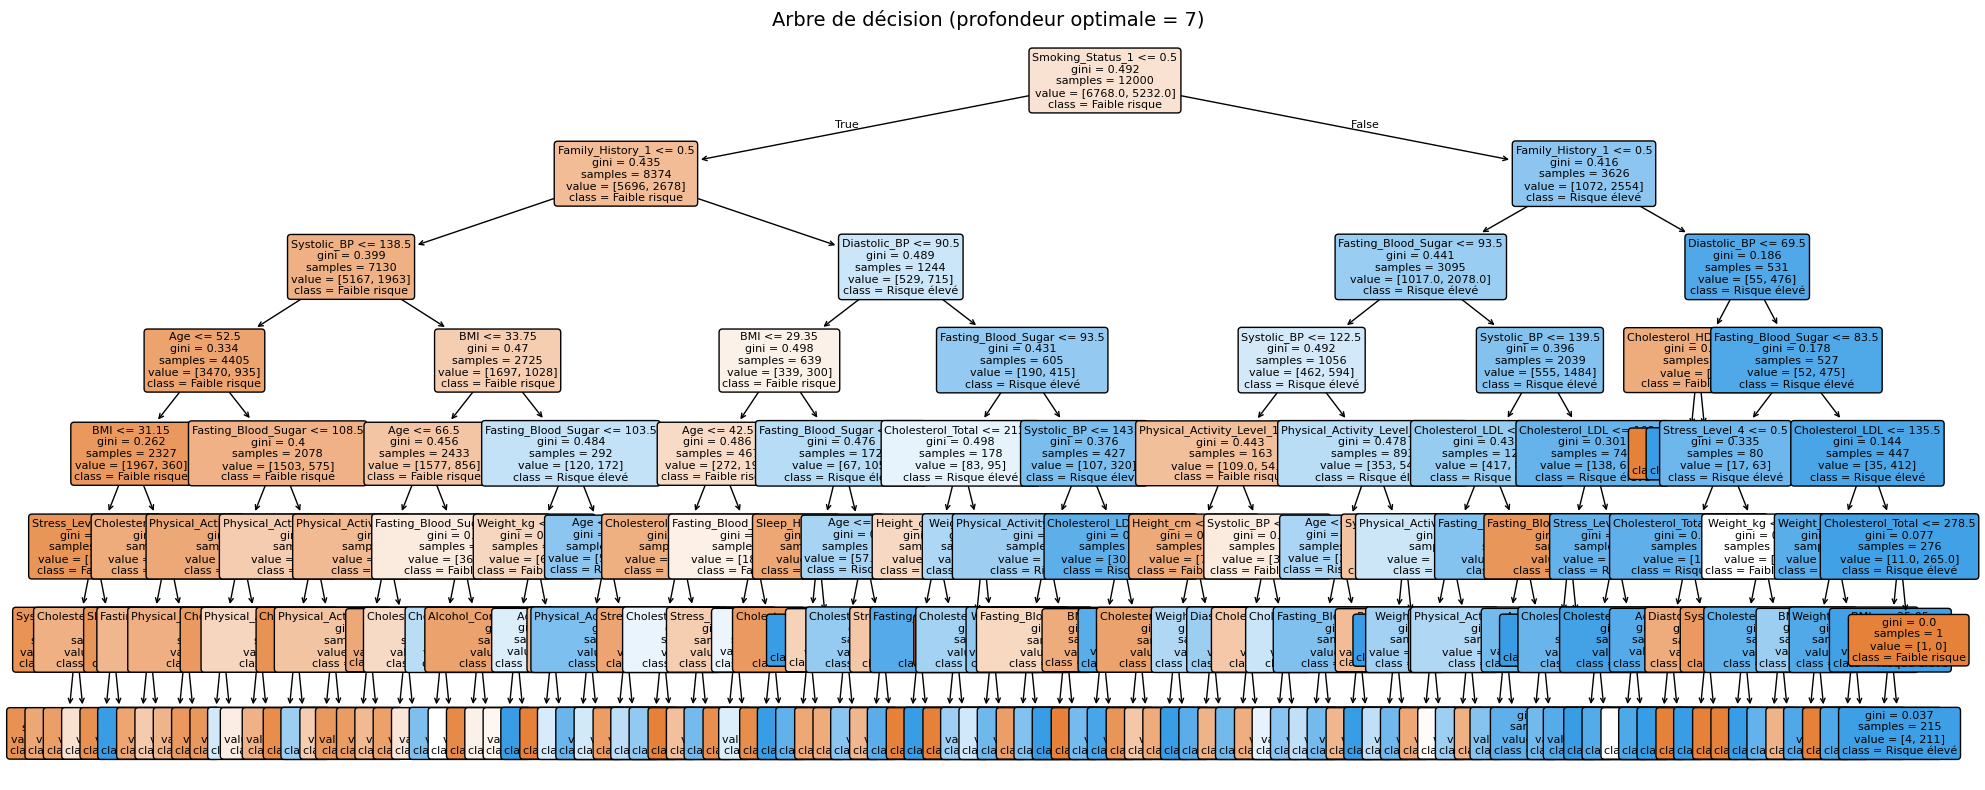

In [31]:
from sklearn.tree import plot_tree

treeG = DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'], random_state=42)
treeG.fit(Xtrain_c, ytrain_c)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(treeG, feature_names=list(feature_names_classif),
          class_names=['Faible risque', 'Risque élevé'],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title(f"Arbre de décision (profondeur optimale = {treeOpt.best_params_['max_depth']})", fontsize=14)
plt.tight_layout()
plt.show()

## 1.5 Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

ts = time.time()
rf = RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42)
rf.fit(Xtrain_c, ytrain_c)
te = time.time()

y_proba_rf = rf.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_rf)
metrics_rf = evaluate_with_threshold(ytest_c, y_proba_rf, best_threshold)

print("Forêt aléatoire")
print(f"Temps : {te-ts:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_rf['recall']:.4f}")
print(f"Precision : {metrics_rf['precision']:.4f}")
print(f"F1-score : {metrics_rf['f1']:.4f}")
print(f"F2-score : {metrics_rf['f2']:.4f}")

Forêt aléatoire
Temps : 1.99 secondes
Seuil optimal : 0.3838
Recall : 0.7768
Precision : 0.6272
F1-score : 0.6940
F2-score : 0.7414


In [33]:
y_pred_opt = (y_proba_rf >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1088,604
Risque élevé,292,1016


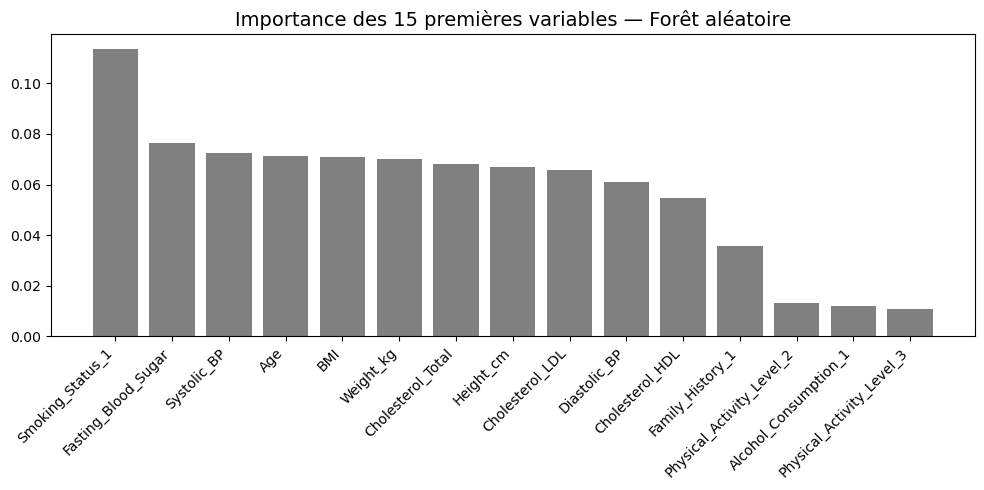

In [34]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances[indices], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_classif[indices], rotation=45, ha='right')
ax.set_title(u"Importance des 15 premières variables — Forêt aléatoire", fontsize=14)
plt.tight_layout()
plt.show()

### Optimisation de `max_features` par validation croisée

Le paramètre `max_features` contrôle le nombre de variables tirées aléatoirement à chaque nœud de chaque arbre. Sa valeur optimale est déterminée par validation croisée, ce qui réduit la corrélation entre les arbres et améliore la généralisation.

In [35]:
ts = time.time()
param_rf = [{"max_features": list(range(2, 12, 2))}]
rf_cv = GridSearchCV(RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42),
                     param_rf, cv=5, n_jobs=1)
rfOpt = rf_cv.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (rfOpt.best_score_, rfOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.726000, Meilleur paramètre = {'max_features': 6}
Temps : 44.78 secondes


In [36]:
y_proba_rf_opt = rfOpt.predict_proba(Xtest_c)[:, 1]
best_threshold_rf_opt, _ = find_optimal_threshold_f1(ytest_c, y_proba_rf_opt)
metrics_rf_opt = evaluate_with_threshold(ytest_c, y_proba_rf_opt, best_threshold_rf_opt)

print("Forêt aléatoire (max_features optimisé)")
print(f"Seuil optimal : {best_threshold_rf_opt:.4f}")
print(f"Recall    : {metrics_rf_opt['recall']:.4f}")
print(f"Precision : {metrics_rf_opt['precision']:.4f}")
print(f"F1-score  : {metrics_rf_opt['f1']:.4f}")
print(f"F2-score  : {metrics_rf_opt['f2']:.4f}")
y_pred_rf_opt = (y_proba_rf_opt >= best_threshold_rf_opt).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_rf_opt), index=labels_risk, columns=labels_risk)

Forêt aléatoire (max_features optimisé)
Seuil optimal : 0.3737
Recall    : 0.7905
Precision : 0.6274
F1-score  : 0.6996
F2-score  : 0.7515

Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1078,614
Risque élevé,274,1034


## 1.6 Boosting

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

ts = time.time()
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(Xtrain_c, ytrain_c)
te = time.time()

y_proba_gb = gb.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_gb)
metrics_gb = evaluate_with_threshold(ytest_c, y_proba_gb, best_threshold)

print("Gradient Boosting (optimisé)")
print(f"Temps : {te-ts:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_gb['recall']:.4f}")
print(f"Precision : {metrics_gb['precision']:.4f}")
print(f"F1-score : {metrics_gb['f1']:.4f}")
print(f"F2-score : {metrics_gb['f2']:.4f}")


Gradient Boosting (optimisé)
Temps : 2.75 secondes
Seuil optimal : 0.3333
Recall : 0.8089
Precision : 0.6227
F1-score : 0.7037
F2-score : 0.7632


In [38]:
y_pred_opt = (y_proba_gb >= best_threshold).astype(int)
print("\nMatrice de confusion (seuil optimal) :")
pd.DataFrame(confusion_matrix(ytest_c, y_pred_opt), index=labels_risk, columns=labels_risk)


Matrice de confusion (seuil optimal) :


,Faible risque,Risque élevé
Faible risque,1051,641
Risque élevé,250,1058


In [39]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}]
gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param, cv=5, n_jobs=1)
gbOpt = gb.fit(Xtrain_c, ytrain_c)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (gbOpt.best_score_, gbOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.734250, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Temps : 93.40 secondes


In [40]:
yChap = gbOpt.predict(Xtest_c)
print("Score sur l'échantillon test : %f" % gbOpt.score(Xtest_c, ytest_c))
pd.DataFrame(confusion_matrix(ytest_c, yChap), index=labels_risk, columns=labels_risk)

Score sur l'échantillon test : 0.729667


,Faible risque,Risque élevé
Faible risque,1367,325
Risque élevé,486,822


## 1.7 Boosting avec toutes les methodes combinées

### Watch out, this took hours to run on my Mac!

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

estimators = [("lasso",BaggingClassifier(LogisticRegression(penalty="l2",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
               ("ridge",BaggingClassifier(LogisticRegression(penalty="l1",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),

               ("kNN", BaggingClassifier(KNeighborsClassifier(), n_estimators = 20, random_state = 42)),
               
               ("boosting", GradientBoostingClassifier(n_estimators=20, learning_rate=0.05,
                                                        max_depth=3, random_state=42)),

               ("svm_gaus", BaggingClassifier(SVC(C=5, gamma=0.01, probability=True, random_state=42),
                                               n_estimators=20, random_state=42)),
            
               ("forets", RandomForestClassifier(n_estimators=20, n_jobs=1, random_state=42)),
               
               ("reg_log", BaggingClassifier(LogisticRegression(solver='liblinear', max_iter=100),
                                              n_estimators = 20, random_state=42)),
                                              
               ("svm_lin", BaggingClassifier(CalibratedClassifierCV(LinearSVC(max_iter=100, random_state=42),
                                                   method='sigmoid', cv=5), n_estimators= 20, random_state=42))]



In [42]:
import os
import time
import joblib

MODEL_PATH = "Savings/b_stacking_model.joblib"
RUNTIME_PATH = "Savings/b_stacking_results.joblib"


TRAIN = False  # TRUE == train, FALSE == load old model

if TRAIN or not os.path.exists(MODEL_PATH):
    ts = time.time()

    b_Stacking = StackingClassifier(
        estimators,
        final_estimator=LogisticRegression()
    )

    b_Stacking.fit(Xtrain_c, ytrain_c)

    te = time.time()
    runtime = te - ts

    joblib.dump(b_Stacking, MODEL_PATH)
    joblib.dump(
        {
            "runtime": runtime
        },
        RUNTIME_PATH
    )

else:
    b_Stacking = joblib.load(MODEL_PATH)
    runtime = joblib.load(RUNTIME_PATH)["runtime"]

y_proba_b_stack = b_Stacking.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_b_stack)
metrics_b_stack = evaluate_with_threshold(ytest_c, y_proba_b_stack, best_threshold)

b_weights = b_Stacking.final_estimator_.coef_[0]

for (name, _), w in zip(estimators, b_weights):
    print(f"{name}: {w:.4f}")

print("Stacking with all Models")
print(f"Temps : {runtime:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_b_stack['recall']:.4f}")
print(f"Precision : {metrics_b_stack['precision']:.4f}")
print(f"F1-score : {metrics_b_stack['f1']:.4f}")
print(f"F2-score : {metrics_b_stack['f2']:.4f}")

lasso: 1.1817
ridge: 1.3589
kNN: 0.0099
boosting: -0.0639
svm_gaus: 0.4217
forets: 0.1243
reg_log: 1.1817
svm_lin: 1.1281
Stacking with all Models
Temps : 1097.70 secondes
Seuil optimal : 0.2929
Recall : 0.8180
Precision : 0.6167
F1-score : 0.7033
F2-score : 0.7679


Explanation to this cell: 

A BaggingClassifier lets the "n_estimators"(20 in our case) train on different subsets of the data.

The "Meta" Classifier ist the Stack boosting Classifier, that assigns different weights to each estimator.


## 1.7.2 Boosting only with the top 3 performant models

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier

top3_estimators = [("lasso",BaggingClassifier(LogisticRegression(penalty="l2",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
                   ("ridge",BaggingClassifier(LogisticRegression(penalty="l1",
                                                             solver='liblinear', max_iter=100),
                                                             n_estimators = 20, random_state = 42)),
                   ("forets", RandomForestClassifier(n_estimators=20, n_jobs=1, random_state=42))]


In [44]:
import os
import time
import joblib

TOP3_MODEL_PATH = "Savings/top3_stacking_model.joblib"
TOP3_RUNTIME_PATH = "Savings/top3_stacking_results.joblib"

TRAIN = False  # TRUE == train, FALSE == load old model

if TRAIN or not os.path.exists(TOP3_MODEL_PATH):
    ts = time.time()

    top3_Stacking = StackingClassifier(
        top3_estimators,
        final_estimator=LogisticRegression()
    )

    top3_Stacking.fit(Xtrain_c, ytrain_c)

    te = time.time()
    runtime = te - ts

    joblib.dump(top3_Stacking, TOP3_MODEL_PATH)
    joblib.dump(
        {
            "runtime": runtime
        },
        TOP3_RUNTIME_PATH)

else:
    top3_Stacking = joblib.load(TOP3_MODEL_PATH)
    runtime = joblib.load(TOP3_RUNTIME_PATH)["runtime"]

y_proba_top3_stack = top3_Stacking.predict_proba(Xtest_c)[:, 1]
best_threshold, best_f1 = find_optimal_threshold_f1(ytest_c, y_proba_top3_stack)
metrics_top3_stack = evaluate_with_threshold(ytest_c, y_proba_top3_stack, best_threshold)

top3_weights = top3_Stacking.final_estimator_.coef_[0]

for (name, _), w in zip(top3_estimators, top3_weights):
    print(f"{name}: {w:.4f}")

print("")
print("Stacking with all Models:")
print(f"Temps : {runtime:.2f} secondes")
print(f"Seuil optimal : {best_threshold:.4f}")
print(f"Recall : {metrics_top3_stack['recall']:.4f}")
print(f"Precision : {metrics_top3_stack['precision']:.4f}")
print(f"F1-score : {metrics_top3_stack['f1']:.4f}")
print(f"F2-score : {metrics_top3_stack['f2']:.4f}")

lasso: 2.3794
ridge: 2.4006
forets: 0.1576

Stacking with all Models:
Temps : 328.28 secondes
Seuil optimal : 0.3030
Recall : 0.8073
Precision : 0.6208
F1-score : 0.7019
F2-score : 0.7616


## 1.9 Réseau de neurones 

In [ ]:
# param_grid=[{"hidden_layer_sizes":list([(5,),(6,),(7,),(8,),(12,),(15,)])}]
# nnet= GridSearchCV(MLPRegressor(max_iter=500),param_grid,cv=10,n_jobs=-1)
# nnetOpt=nnet.fit(Xtrain_r, ytrain_r)
# # paramètre optimal
# print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - nnetOpt.best_score_,nnetOpt.best_params_))

## 1.8 Comparaison des modèles — `Heart_Disease_Risk`

Tous les modèles optimisés sont comparés sur l'échantillon test.

In [45]:
resultats_classif = pd.DataFrame({
    "Modèle": [
        "Régression logistique (LASSO)",
        "Régression logistique (Ridge)",
        "Régression logistique",
        "SVM linéaire",
        "SVM noyau gaussien (optimisé)",
        "kNN (optimisé)",
        "knn moins de variables",
        "Gradient Boosting (optimisé)",
        "Forêt aléatoire",
        "Forêt aléatoire (max_features opt.)",
        "Stack Boosting de toutes les models",
        "Stack Boosting avec les top 3 models"
    ],
    "Seuil": [
        metrics_lasso['threshold'],
        metrics_ridge['threshold'],
        metrics_logit['threshold'],
        metrics_svm_lin['threshold'],
        metrics_svm_rbf['threshold'],
        metrics_knn['threshold'],
        metrics_knn_var['threshold'],
        metrics_gb['threshold'],
        metrics_rf['threshold'],
        metrics_rf_opt['threshold'],
        metrics_b_stack['threshold'],
        metrics_top3_stack['threshold'],
    ],
    "Recall": [
        metrics_lasso['recall'],
        metrics_ridge['recall'],
        metrics_logit['recall'],
        metrics_svm_lin['recall'],
        metrics_svm_rbf['recall'],
        metrics_knn['recall'],
        metrics_knn_var['recall'],
        metrics_gb['recall'],
        metrics_rf['recall'],
        metrics_rf_opt['recall'],
        metrics_b_stack['recall'],
        metrics_top3_stack['recall'],
    ],
    "Precision": [
        metrics_lasso['precision'],
        metrics_ridge['precision'],
        metrics_logit['precision'],
        metrics_svm_lin['precision'],
        metrics_svm_rbf['precision'],
        metrics_knn['precision'],
        metrics_knn_var['precision'], 
        metrics_gb['precision'],
        metrics_rf['precision'],
        metrics_rf_opt['precision'],
        metrics_b_stack['precision'],
        metrics_top3_stack['precision'],
    ],
    "F1": [
        metrics_lasso['f1'],
        metrics_ridge['f1'],
        metrics_logit['f1'],
        metrics_svm_lin['f1'],
        metrics_svm_rbf['f1'],
        metrics_knn['f1'],
        metrics_knn_var['f1'],
        metrics_gb['f1'],
        metrics_rf['f1'],
        metrics_rf_opt['f1'],
        metrics_b_stack['f1'],
        metrics_top3_stack['f1'],
    ],
    "F2": [
        metrics_lasso['f2'],
        metrics_ridge['f2'],
        metrics_logit['f2'],
        metrics_svm_lin['f2'],
        metrics_svm_rbf['f2'],
        metrics_knn['f2'],
        metrics_knn_var['f2'],
        metrics_gb['f2'],
        metrics_rf['f2'],
        metrics_rf_opt['f2'],
        metrics_b_stack['f2'],
        metrics_top3_stack['f2'],
    ]
}).sort_values("F2", ascending=False).reset_index(drop=True)

print("\nComparaison des modèles avec seuil optimisé sur F1")
resultats_classif_display = resultats_classif.copy()
for col in ["Seuil", "Recall", "Precision", "F1", "F2"]:
    resultats_classif_display[col] = resultats_classif_display[col].map("{:.4f}".format)
display(resultats_classif_display)

print("\nLe F2-score donne plus de poids au recall (détection des malades)")
print("Meilleur modèle :", resultats_classif.iloc[0]["Modèle"])


Comparaison des modèles avec seuil optimisé sur F1


,Modèle,Seuil,Recall,Precision,F1,F2
0,Régression logistique (Ridge),0.2828,0.8540,0.5948,0.7012,0.7855
1,Régression logistique (LASSO),0.3030,0.8295,0.6072,0.7011,0.7729
2,Stack Boosting de toutes les models,0.2929,0.8180,0.6167,0.7033,0.7679
3,Gradient Boosting (optimisé),0.3333,0.8089,0.6227,0.7037,0.7632
4,Stack Boosting avec les top 3 models,0.3030,0.8073,0.6208,0.7019,0.7616
5,SVM noyau gaussien (optimisé),0.2929,0.7959,0.6222,0.6984,0.7538
6,kNN (optimisé),0.3535,0.8127,0.5831,0.6790,0.7534
7,knn moins de variables,0.3131,0.8043,0.5994,0.6869,0.7528
8,Régression logistique,0.3434,0.7913,0.6296,0.7012,0.7526
9,Forêt aléatoire (max_features opt.),0.3737,0.7905,0.6274,0.6996,0.7515



Le F2-score donne plus de poids au recall (détection des malades)
Meilleur modèle : Régression logistique (Ridge)


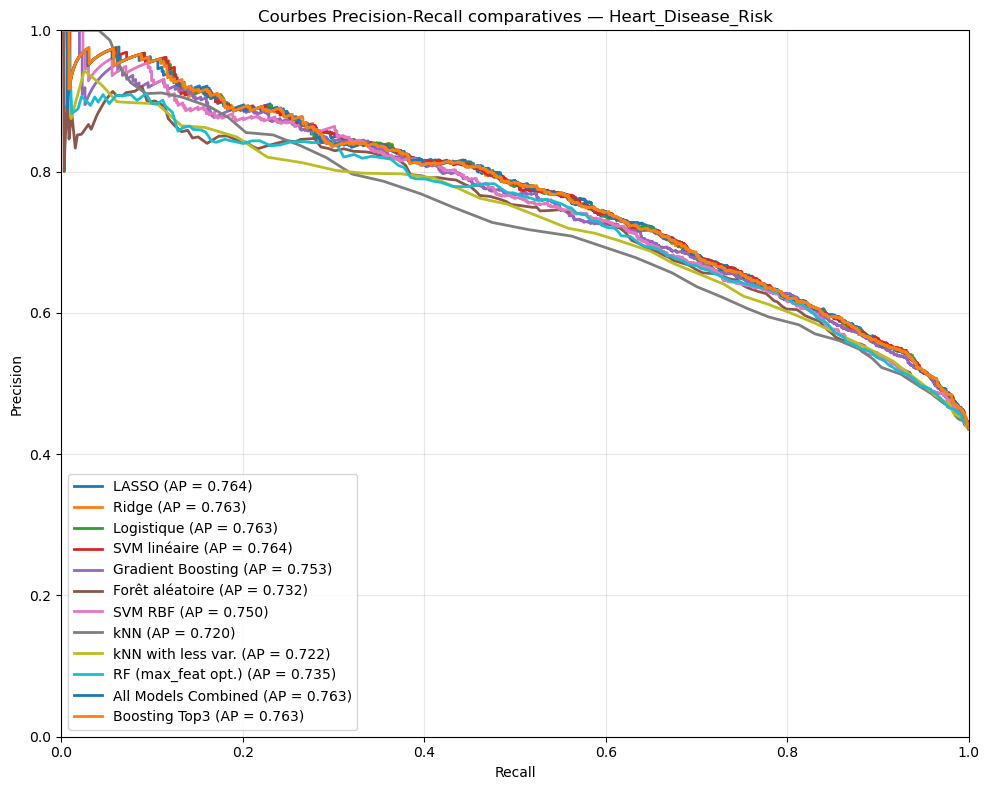

In [46]:
# =============================================================================
# Courbes Precision-Recall comparatives
# =============================================================================

plt.figure(figsize=(10, 8))

models_probas = [y_proba_lasso, y_proba_ridge, y_proba_logit, y_proba_svm_lin, 
                 y_proba_gb, y_proba_rf, y_proba_svm_rbf, y_proba_knn, y_proba_knn_var, y_proba_rf_opt, y_proba_b_stack, y_proba_top3_stack]
models_names = ["LASSO", "Ridge", "Logistique", "SVM linéaire", 
                "Gradient Boosting", "Forêt aléatoire", "SVM RBF", "kNN","kNN with less var.", "RF (max_feat opt.)",
                "All Models Combined", "Boosting Top3"]

for proba, name in zip(models_probas, models_names):
    precision, recall, _ = precision_recall_curve(ytest_c, proba)
    ap = average_precision_score(ytest_c, proba)
    plt.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbes Precision-Recall comparatives — Heart_Disease_Risk')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

### Courbes ROC comparatives

Les courbes ROC (Receiver Operating Characteristic) représentent le taux de vrais positifs en fonction du taux de faux positifs pour différents seuils de décision. L'aire sous la courbe (AUC-ROC) permet de comparer les modèles indépendamment du seuil choisi.

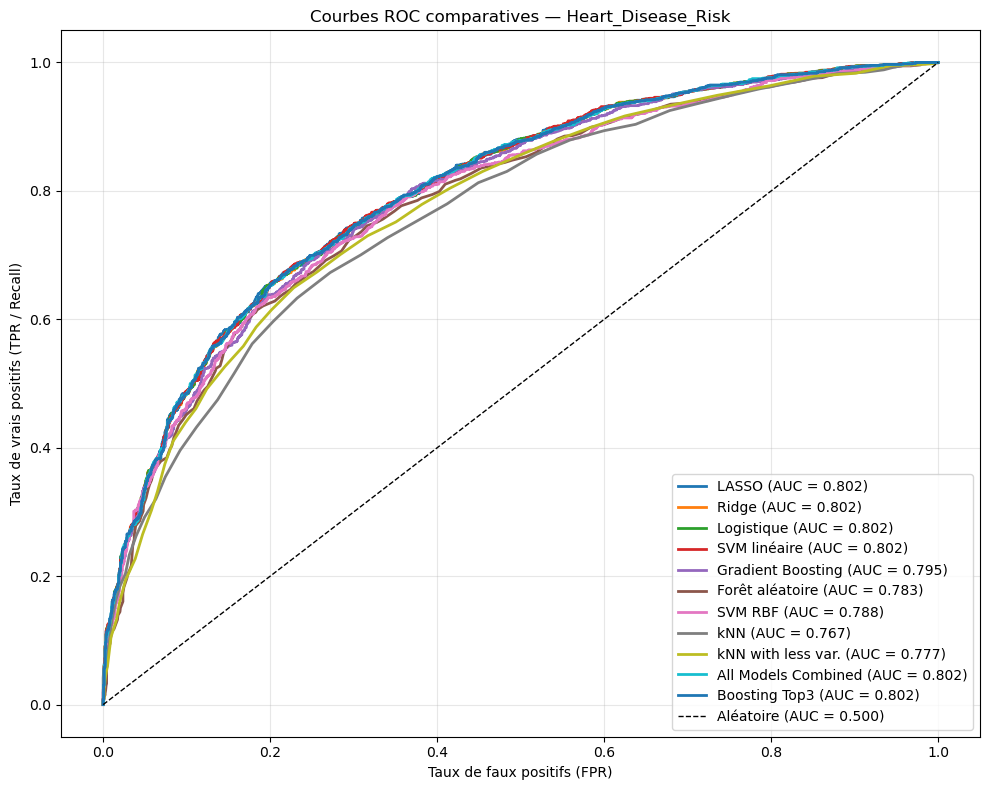

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

models_probas_roc = [
    (y_proba_lasso,   "LASSO"),
    (y_proba_ridge,   "Ridge"),
    (y_proba_logit,   "Logistique"),
    (y_proba_svm_lin, "SVM linéaire"),
    (y_proba_gb,      "Gradient Boosting"),
    (y_proba_rf,      "Forêt aléatoire"),
    (y_proba_svm_rbf, "SVM RBF"),
    (y_proba_knn,     "kNN"),
    (y_proba_knn_var, "kNN with less var."),
    (y_proba_b_stack, "All Models Combined"),
    (y_proba_top3_stack, "Boosting Top3")
]

for proba, name in models_probas_roc:
    fpr, tpr, _ = roc_curve(ytest_c, proba)
    auc = roc_auc_score(ytest_c, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.500)')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR / Recall)')
plt.title('Courbes ROC comparatives — Heart_Disease_Risk')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2 Prédiction de la variable `Cholesterol_LDL`

## 2.1 Préparation des données — Régression

Faut excluer la variable `Heart_Disease_Risk`.

In [48]:
y_reg = df_encoded["Cholesterol_LDL"].values
X_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).values
feature_names_reg = df_encoded.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"]).columns

Xtrain_r, Xtest_r, ytrain_r, ytest_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xtrain_r_sc = scaler_r.fit_transform(Xtrain_r)
Xtest_r_sc  = scaler_r.transform(Xtest_r)

print("Echantillon d'apprentissage :", Xtrain_r.shape[0], "observations")
print("Echantillon test            :", Xtest_r.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


In [49]:
feature_names_reg

Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP',
       'Cholesterol_Total', 'Cholesterol_HDL', 'Fasting_Blood_Sugar',
       'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1',
       'Physical_Activity_Level_2', 'Physical_Activity_Level_3',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1',
       'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5',
       'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10'],
      dtype='object')

## 2.2 Modèles linéaires

### 2.2.1 Régression linéaire

#### Estimation sans régularisation

In [50]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

ts = time.time()
lr = LinearRegression()
lr.fit(Xtrain_r, ytrain_r)
ypred = lr.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.693690
RMSE test : 9.796619
Temps d'exécution : 0.02 secondes



#### Optimisation par pénalisation Ridge (L2)



In [51]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
ridge = GridSearchCV(Ridge(), param, cv=5, n_jobs=1, scoring='r2')
ridgeOpt = ridge.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (ridgeOpt.best_score_, ridgeOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.685860, Meilleur paramètre = {'alpha': 100}
Temps : 0.18 secondes


In [52]:
yChap = ridgeOpt.predict(Xtest_r)
print("R² test (Ridge) : %f" % r2_score(ytest_r, yChap))
print("RMSE test (Ridge) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (Ridge) : 0.693849
RMSE test (Ridge) : 9.794086


#### Optimisation par pénalisation LASSO (L1) et sélection de variables

In [53]:
ts = time.time()
param = [{"alpha": [0.01, 0.1, 1, 10, 100]}]
lasso = GridSearchCV(Lasso(max_iter=5000), param, cv=5, n_jobs=1, scoring='r2')
lassoOpt = lasso.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (lassoOpt.best_score_, lassoOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.686743, Meilleur paramètre = {'alpha': 1}
Temps : 0.32 secondes


In [54]:
yChap = lassoOpt.predict(Xtest_r)
print("R² test (LASSO) : %f" % r2_score(ytest_r, yChap))
print("RMSE test (LASSO) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (LASSO) : 0.694489
RMSE test (LASSO) : 9.783834


In [55]:
coef_lasso = lassoOpt.best_estimator_.coef_
variables_selectionnees_r = feature_names_reg[coef_lasso != 0]
print("Variables sélectionnées par le LASSO (%d / %d) :" % (len(variables_selectionnees_r), len(feature_names_reg)))
print(variables_selectionnees_r.tolist())

Variables sélectionnées par le LASSO (3 / 32) :
['Age', 'Systolic_BP', 'Cholesterol_Total']


## 2.3 kNN (régression)

Le régresseur k plus proches voisins (`KNeighborsRegressor`) prédit la valeur cible comme la moyenne des k plus proches voisins. L'hyperparamètre `k` est optimisé par validation croisée. Les données sont standardisées au préalable.

In [56]:
from sklearn.neighbors import KNeighborsRegressor

ts = time.time()
param_grid_r = [{"n_neighbors": list(range(1, 21))}]
knn_r = GridSearchCV(KNeighborsRegressor(), param_grid_r, cv=10, n_jobs=1, scoring='r2')
knnROpt = knn_r.fit(Xtrain_r_sc, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (knnROpt.best_score_, knnROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.368661, Meilleur paramètre = {'n_neighbors': 20}
Temps : 2.25 secondes


R² test (kNN) : 0.378929
RMSE test (kNN) : 13.949750


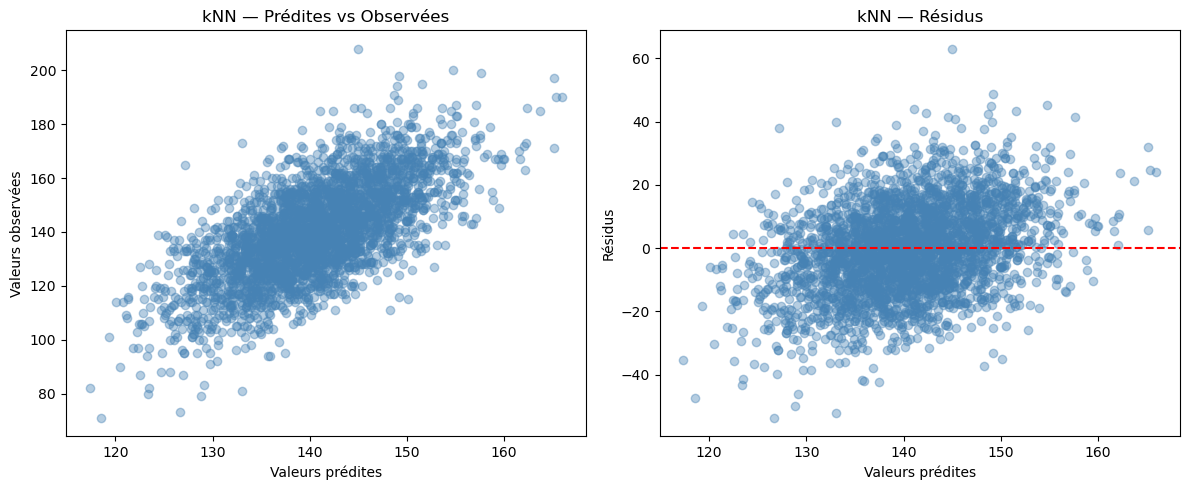

In [57]:
yChap_knn_r = knnROpt.predict(Xtest_r_sc)
print("R² test (kNN) : %f" % r2_score(ytest_r, yChap_knn_r))
print("RMSE test (kNN) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap_knn_r)))

# Graphe des résidus
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_knn_r, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Valeurs observées")
axes[0].set_title("kNN — Prédites vs Observées")

axes[1].scatter(yChap_knn_r, ytest_r - yChap_knn_r, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Valeurs prédites")
axes[1].set_ylabel("Résidus")
axes[1].set_title("kNN — Résidus")

plt.tight_layout()
plt.show()

## 2.3.2 kNN Regression with less variables

In [58]:
X_reg_kNN = df_encoded.drop(columns=["Cholesterol_LDL", 'Height_cm', 'Weight_kg', 'BMI', 'Diastolic_BP',
       'Cholesterol_HDL', 'Fasting_Blood_Sugar',
       'Gender_1', 'Smoking_Status_1', 'Physical_Activity_Level_1',
       'Physical_Activity_Level_2', 'Physical_Activity_Level_3',
       'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Family_History_1',
       'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5',
       'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9',
       'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7',
       'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10' ]).values.copy()

# Here we keep the Variables only based on the PCA of the numerical Variables: Cholesterol Total, Stylostic BP, Age

Xtrain_r_kNN, Xtest_r_kNN, ytrain_r, ytest_r = train_test_split(
    X_reg_kNN, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xtrain_r_sc_kNN = scaler_r.fit_transform(Xtrain_r_kNN)
Xtest_r_sc_kNN  = scaler_r.transform(Xtest_r_kNN)

print("Echantillon d'apprentissage :", Xtrain_r_kNN.shape[0], "observations")
print("Echantillon test            :", Xtest_r_kNN.shape[0], "observations")

Echantillon d'apprentissage : 12000 observations
Echantillon test            : 3000 observations


In [59]:
from sklearn.neighbors import KNeighborsRegressor

ts = time.time()
param_grid_r = [{"n_neighbors": list(range(1, 100))}]
knn_var_r = GridSearchCV(KNeighborsRegressor(), param_grid_r, cv=10, n_jobs=1, scoring='r2')
knn_var_ROpt = knn_var_r.fit(Xtrain_r_sc_kNN, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (knn_var_ROpt.best_score_, knn_var_ROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.671303, Meilleur paramètre = {'n_neighbors': 37}
Temps : 11.01 secondes


R² test (kNN) : 0.676031
RMSE test (kNN) : 10.075053


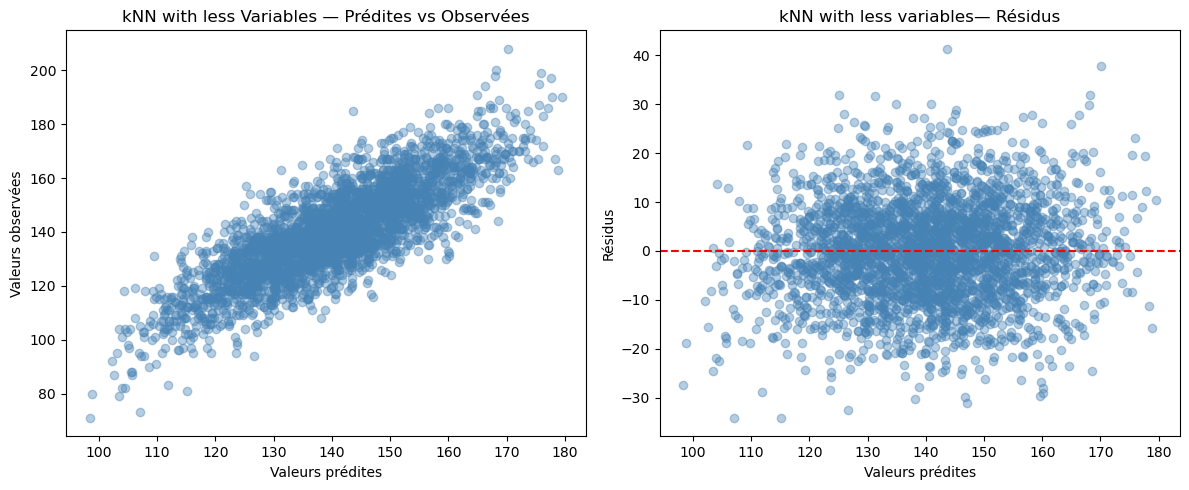

In [60]:
yChap_knn_var_r = knn_var_ROpt.predict(Xtest_r_sc_kNN)
print("R² test (kNN) : %f" % r2_score(ytest_r, yChap_knn_var_r))
print("RMSE test (kNN) : %f" % np.sqrt(mean_squared_error(ytest_r, yChap_knn_var_r)))

# Graphe des résidus
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_knn_var_r, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Valeurs observées")
axes[0].set_title("kNN with less Variables — Prédites vs Observées")

axes[1].scatter(yChap_knn_var_r, ytest_r - yChap_knn_var_r, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Valeurs prédites")
axes[1].set_ylabel("Résidus")
axes[1].set_title("kNN with less variables— Résidus")

plt.tight_layout()
plt.show()

We can observe a real improvement to the kNN on all Variables!

## 2.4 SVR

### 2.4.1 SVR linéaire

In [61]:
from sklearn.svm import LinearSVR

ts = time.time()
method = LinearSVR(max_iter=5000)
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.693354
RMSE test : 9.801999
Temps d'exécution : 0.03 secondes


### 2.4.2 SVR avec noyau gaussien

In [62]:
from sklearn.svm import SVR

ts = time.time()
method = SVR(gamma='auto')
method.fit(Xtrain_r_sc, ytrain_r)
ypred = method.predict(Xtest_r_sc)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.647474
RMSE test : 10.509731
Temps d'exécution : 4.20 secondes


In [63]:
ts = time.time()
param = [{"C": [1, 5, 10], "gamma": [0.001, 0.01, 0.1]}]
svr = GridSearchCV(SVR(), param, cv=5, n_jobs=1, scoring='r2')
svrOpt = svr.fit(Xtrain_r_sc, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (svrOpt.best_score_, svrOpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.680925, Meilleur paramètre = {'C': 10, 'gamma': 0.001}
Temps : 124.51 secondes


In [64]:
yChap = svrOpt.predict(Xtest_r_sc)
print("R² test (SVR RBF optimisé) : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (SVR RBF optimisé) : 0.690313
RMSE test : 9.850485


## 2.5 Arbre optimal


In [65]:
from sklearn.tree import DecisionTreeRegressor

ts = time.time()
param = [{"max_depth": [3, 5, 7, 10, 15, None]}]
tree_r = GridSearchCV(DecisionTreeRegressor(random_state=42), param, cv=5, n_jobs=1, scoring='r2')
treeROpt = tree_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (treeROpt.best_score_, treeROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.679484, Meilleur paramètre = {'max_depth': 5}
Temps : 1.23 secondes


In [66]:
yChap = treeROpt.predict(Xtest_r)
print("R² test : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test : 0.687738
RMSE test : 9.891349


## 2.6 Random Forest



In [67]:
from sklearn.ensemble import RandomForestRegressor

ts = time.time()
method = RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.675677
RMSE test : 10.080556
Temps d'exécution : 9.83 secondes


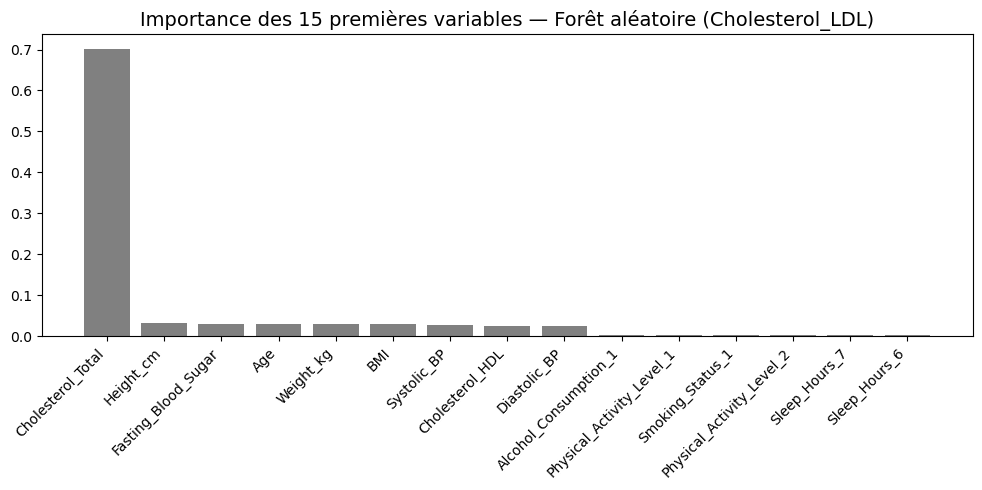

In [68]:
importances_r = method.feature_importances_
indices_r = np.argsort(importances_r)[::-1][:15]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.bar(range(15), importances_r[indices_r], align='center', color='grey', ecolor='black')
ax.set_xticks(range(15))
ax.set_xticklabels(feature_names_reg[indices_r], rotation=45, ha='right')
ax.set_title(u"Importance des 15 premières variables — Forêt aléatoire (Cholesterol_LDL)", fontsize=14)
plt.tight_layout()
plt.show()

## 2.7 Boosting

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

ts = time.time()
method = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
method.fit(Xtrain_r, ytrain_r)
ypred = method.predict(Xtest_r)
te = time.time()

print("R² test : %f" % r2_score(ytest_r, ypred))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, ypred)))
print("Temps d'exécution : %.2f secondes" % (te - ts))

R² test : 0.684023
RMSE test : 9.950005
Temps d'exécution : 3.32 secondes


In [70]:
ts = time.time()
param = [{"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]}]
gb_r = GridSearchCV(GradientBoostingRegressor(random_state=42), param, cv=5, n_jobs=1, scoring='r2')
gbROpt = gb_r.fit(Xtrain_r, ytrain_r)
te = time.time()
print("Meilleur score = %f, Meilleur paramètre = %s" % (gbROpt.best_score_, gbROpt.best_params_))
print("Temps : %.2f secondes" % (te - ts))

Meilleur score = 0.683337, Meilleur paramètre = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Temps : 80.46 secondes


In [71]:
yChap = gbROpt.predict(Xtest_r)
print("R² test (optimisé) : %f" % r2_score(ytest_r, yChap))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap)))

R² test (optimisé) : 0.691548
RMSE test : 9.830823


## 2.8 Réseau de neurones

In [72]:
from sklearn.neural_network import MLPRegressor

In [77]:
param_grid=[{"hidden_layer_sizes":list([(5,),(6,),(7,),(8,),(12,),(15,)])}]
nnet= GridSearchCV(MLPRegressor(max_iter=500),param_grid,cv=10,n_jobs=-1)
nnetOpt=nnet.fit(Xtrain_r, ytrain_r)
# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - nnetOpt.best_score_,nnetOpt.best_params_))

Meilleur score = 0.316062, Meilleur paramètre = {'hidden_layer_sizes': (8,)}


In [78]:
yChap_nn = nnetOpt.predict(Xtest_r)
print("R² test (optimisé) : %f" % r2_score(ytest_r, yChap_nn))
print("RMSE test : %f" % np.sqrt(mean_squared_error(ytest_r, yChap_nn)))

R² test (optimisé) : 0.691908
RMSE test : 9.825084


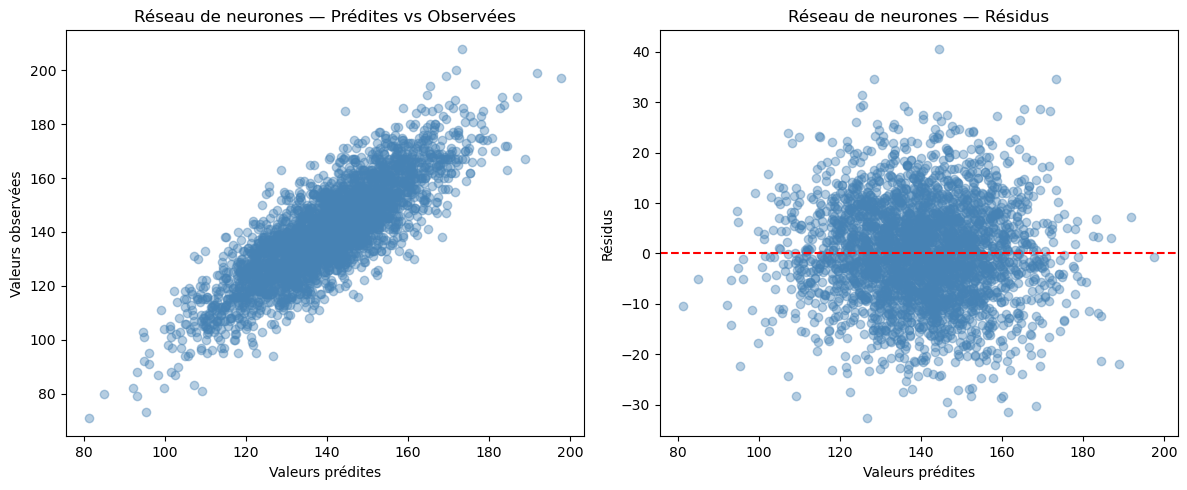

In [79]:
# Graphe des résidus
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yChap_nn, ytest_r, alpha=0.4, color='steelblue')
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Valeurs observées")
axes[0].set_title("Réseau de neurones — Prédites vs Observées")

axes[1].scatter(yChap_nn, ytest_r - yChap_nn, alpha=0.4, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Valeurs prédites")
axes[1].set_ylabel("Résidus")
axes[1].set_title("Réseau de neurones — Résidus")

plt.tight_layout()
plt.show()

## 2.9 Comparaison des modèles — `Cholesterol_LDL`

In [80]:
yChap_knn_r = knnROpt.predict(Xtest_r_sc)

r2_scores = [
    r2_score(ytest_r, lr.predict(Xtest_r)),
    r2_score(ytest_r, ridgeOpt.predict(Xtest_r)),
    r2_score(ytest_r, lassoOpt.predict(Xtest_r)),
    r2_score(ytest_r, knnROpt.predict(Xtest_r_sc)),
    r2_score(ytest_r, knn_var_ROpt.predict(Xtest_r_sc_kNN)),
    r2_score(ytest_r, LinearSVR(max_iter=5000).fit(Xtrain_r_sc, ytrain_r).predict(Xtest_r_sc)),
    r2_score(ytest_r, svrOpt.predict(Xtest_r_sc)),
    r2_score(ytest_r, treeROpt.predict(Xtest_r)),
    r2_score(ytest_r, RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42).fit(Xtrain_r, ytrain_r).predict(Xtest_r)),
    r2_score(ytest_r, gbROpt.predict(Xtest_r)),
    r2_score(ytest_r, nnetOpt.predict(Xtest_r))
]

rmse_scores = [
    np.sqrt(mean_squared_error(ytest_r, lr.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, ridgeOpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, lassoOpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, knnROpt.predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, knn_var_ROpt.predict(Xtest_r_sc_kNN))),
    np.sqrt(mean_squared_error(ytest_r, LinearSVR(max_iter=5000).fit(Xtrain_r_sc, ytrain_r).predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, svrOpt.predict(Xtest_r_sc))),
    np.sqrt(mean_squared_error(ytest_r, treeROpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, RandomForestRegressor(n_estimators=200, n_jobs=1, random_state=42).fit(Xtrain_r, ytrain_r).predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, gbROpt.predict(Xtest_r))),
    np.sqrt(mean_squared_error(ytest_r, nnetOpt.predict(Xtest_r)))
]

resultats_reg = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Ridge (optimisé)",
        "LASSO (optimisé)",
        "kNN (optimisé)",
        "kNN with less variables",
        "SVR linéaire",
        "SVR noyau gaussien (optimisé)",
        "Arbre de décision (optimisé)",
        "Forêt aléatoire",
        "Gradient Boosting (optimisé)",
        "Réseau de neurones"
    ],
    "R² test": r2_scores,
    "RMSE test": rmse_scores
}).sort_values("R² test", ascending=False).reset_index(drop=True)

resultats_reg["R² test"] = resultats_reg["R² test"].map("{:.4f}".format)
resultats_reg["RMSE test"] = resultats_reg["RMSE test"].map("{:.4f}".format)
resultats_reg

,Modèle,R² test,RMSE test
0,LASSO (optimisé),0.6945,9.7838
1,Ridge (optimisé),0.6938,9.7941
2,Régression linéaire,0.6937,9.7966
3,SVR linéaire,0.6936,9.8025
4,Réseau de neurones,0.6919,9.8251
5,Gradient Boosting (optimisé),0.6915,9.8308
6,SVR noyau gaussien (optimisé),0.6903,9.8505
7,Arbre de décision (optimisé),0.6877,9.8913
8,kNN with less variables,0.6760,10.0751
9,Forêt aléatoire,0.6757,10.0806
